# Economic Data Analysis with Pandas 
from [Youtube] (https://www.youtube.com/watch?v=R67XuYc9NQ4)

Set up api key in .env file
Be sure to use .gitignore to exlude .env file



In [49]:
from dotenv import load_dotenv
import os
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import time

plt.style.use('fivethirtyeight')
pd.set_option('display.max_columns', 500)
color_pal = plt.rcParams["axes.prop_cycle"].by_key()["color"]

from fredapi import Fred

load_dotenv()

api_key = os.getenv("FRED_API_KEY")

# Fred Object
fred = Fred(api_key=api_key)

In [50]:
print("Key loaded:", api_key is not None)

Key loaded: True


### Search for economic data

In [51]:
sp_search = fred.search("S&P 500", order_by="popularity", limit=5)

In [52]:
sp_search.shape

(5, 15)

In [53]:
sp_search.head()

,id,realtime_start,realtime_end,title,observation_start,observation_end,frequency,frequency_short,units,units_short,seasonal_adjustment,seasonal_adjustment_short,last_updated,popularity,notes
series id,,,,,,,,,,,,,,,
SP500,SP500,2026-03-12,2026-03-12,S&P 500,2016-03-14,2026-03-11,"Daily, Close",D,Index,Index,Not Seasonally Adjusted,NSA,2026-03-11 19:01:52-05:00,90,The observations for the S&P 500 represent the...
MEHOINUSA646N,MEHOINUSA646N,2026-03-12,2026-03-12,Median Household Income in the United States,1984-01-01,2024-01-01,Annual,A,Current Dollars,Current $,Not Seasonally Adjusted,NSA,2025-09-09 13:19:03-05:00,72,Household data are collected as of March. As ...
VXVCLS,VXVCLS,2026-03-12,2026-03-12,CBOE S&P 500 3-Month Volatility Index,2007-12-04,2026-03-11,"Daily, Close",D,Index,Index,Not Seasonally Adjusted,NSA,2026-03-12 08:37:30-05:00,61,"Copyright, 2016, Chicago Board Options Exchang..."
MEHOINUSCAA646N,MEHOINUSCAA646N,2026-03-12,2026-03-12,Median Household Income in California,1984-01-01,2024-01-01,Annual,A,Current Dollars,Current $,Not Seasonally Adjusted,NSA,2025-09-09 13:19:04-05:00,51,Household data are collected as of March. As ...
EMVOVERALLEMV,EMVOVERALLEMV,2026-03-12,2026-03-12,Equity Market Volatility Tracker: Overall,1985-01-01,2026-02-01,Monthly,M,Index,Index,Not Seasonally Adjusted,NSA,2026-03-04 08:02:55-06:00,48,The Equity Market Volatility tracker moves wit...


### 3. Pull Raw Data & Plot

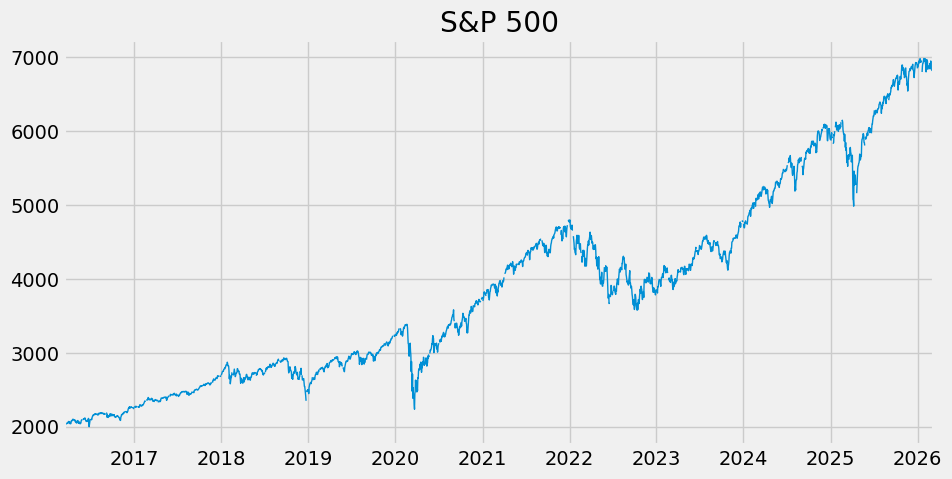

In [54]:
sp500 = fred.get_series(series_id='SP500')
sp500.plot(figsize=(10, 5), title='S&P 500', lw=1)
plt.show()

### 4. Pull and Join Multiple Data Series


In [55]:
uemp_results = fred.search('unemployment')
uemp_results 

,id,realtime_start,realtime_end,title,observation_start,observation_end,frequency,frequency_short,units,units_short,seasonal_adjustment,seasonal_adjustment_short,last_updated,popularity,notes
series id,,,,,,,,,,,,,,,
UNRATE,UNRATE,2026-03-12,2026-03-12,Unemployment Rate,1948-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-03-06 08:12:35-06:00,98,The unemployment rate represents the number of...
UNRATENSA,UNRATENSA,2026-03-12,2026-03-12,Unemployment Rate,1948-01-01,2026-02-01,Monthly,M,Percent,%,Not Seasonally Adjusted,NSA,2026-03-06 08:13:10-06:00,57,The unemployment rate represents the number of...
UNEMPLOY,UNEMPLOY,2026-03-12,2026-03-12,Unemployment Level,1948-01-01,2026-02-01,Monthly,M,Thousands of Persons,Thous. of Persons,Seasonally Adjusted,SA,2026-03-06 08:12:53-06:00,74,The series comes from the 'Current Population ...
NROU,NROU,2026-03-12,2026-03-12,Noncyclical Rate of Unemployment,1949-01-01,2036-10-01,Quarterly,Q,Percent,%,Not Seasonally Adjusted,NSA,2026-02-27 15:05:27-06:00,69,"Starting with the July, 2021 report: An Update..."
U6RATE,U6RATE,2026-03-12,2026-03-12,"Total Unemployed, Plus All Persons Marginally ...",1994-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-03-06 08:13:00-06:00,73,The series comes from the 'Current Population ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENUC120640510SA,ENUC120640510SA,2026-03-12,2026-03-12,Average Weekly Wages for Employees in Private ...,1990-01-01,2025-07-01,Quarterly,Q,Dollars per Week,$ per Week,Seasonally Adjusted,SA,2026-03-10 11:32:31-05:00,1,Average weekly wages are the wages paid by une...
ENUC455040210,ENUC455040210,2026-03-12,2026-03-12,Average Weekly Wages for Employees in State Go...,1990-01-01,2025-04-01,Quarterly,Q,Dollars per Week,$ per Week,Not Seasonally Adjusted,NSA,2025-12-19 11:20:23-06:00,1,Average weekly wages are the wages paid by une...
ENUC455040210SA,ENUC455040210SA,2026-03-12,2026-03-12,Average Weekly Wages for Employees in State Go...,1990-01-01,2025-07-01,Quarterly,Q,Dollars per Week,$ per Week,Seasonally Adjusted,SA,2026-03-10 11:27:51-05:00,1,Average weekly wages are the wages paid by une...


In [56]:
unrate = fred.get_series('unrate')

<Axes: >

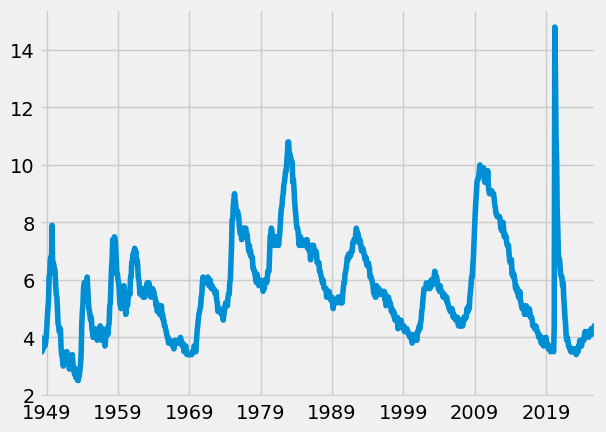

In [57]:
unrate.plot()

In [58]:
fred.search('unemployment rate state', filter=('frequency', 'Monthly'))

,id,realtime_start,realtime_end,title,observation_start,observation_end,frequency,frequency_short,units,units_short,seasonal_adjustment,seasonal_adjustment_short,last_updated,popularity,notes
series id,,,,,,,,,,,,,,,
UNRATE,UNRATE,2026-03-12,2026-03-12,Unemployment Rate,1948-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-03-06 08:12:35-06:00,98,The unemployment rate represents the number of...
UNRATENSA,UNRATENSA,2026-03-12,2026-03-12,Unemployment Rate,1948-01-01,2026-02-01,Monthly,M,Percent,%,Not Seasonally Adjusted,NSA,2026-03-06 08:13:10-06:00,57,The unemployment rate represents the number of...
UNEMPLOY,UNEMPLOY,2026-03-12,2026-03-12,Unemployment Level,1948-01-01,2026-02-01,Monthly,M,Thousands of Persons,Thous. of Persons,Seasonally Adjusted,SA,2026-03-06 08:12:53-06:00,74,The series comes from the 'Current Population ...
U6RATE,U6RATE,2026-03-12,2026-03-12,"Total Unemployed, Plus All Persons Marginally ...",1994-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-03-06 08:13:00-06:00,73,The series comes from the 'Current Population ...
LNU03000000,LNU03000000,2026-03-12,2026-03-12,Unemployment Level,1948-01-01,2026-02-01,Monthly,M,Thousands of Persons,Thous. of Persons,Not Seasonally Adjusted,NSA,2026-03-06 08:14:10-06:00,29,The series comes from the 'Current Population ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LAUCN361190000000005,LAUCN361190000000005,2026-03-12,2026-03-12,"Employed Persons in Westchester County, NY",1990-01-01,2025-12-01,Monthly,M,Persons,Persons,Not Seasonally Adjusted,NSA,2026-02-06 19:18:54-06:00,1,These data come from the Current Population Su...
LAUCN515100000000005,LAUCN515100000000005,2026-03-12,2026-03-12,"Employed Persons in Alexandria City, VA",1990-01-01,2025-12-01,Monthly,M,Persons,Persons,Not Seasonally Adjusted,NSA,2026-02-06 19:15:42-06:00,1,These data come from the Current Population Su...
NDDUNN5LFN,NDDUNN5LFN,2026-03-12,2026-03-12,"Civilian Labor Force in Dunn County, ND",1990-01-01,2025-12-01,Monthly,M,Persons,Persons,Not Seasonally Adjusted,NSA,2026-02-06 19:13:20-06:00,1,These data come from the Current Population Su...


In [59]:
unemp_df = fred.search('unemployment rate state', filter=('frequency','Monthly'))
unemp_df 

,id,realtime_start,realtime_end,title,observation_start,observation_end,frequency,frequency_short,units,units_short,seasonal_adjustment,seasonal_adjustment_short,last_updated,popularity,notes
series id,,,,,,,,,,,,,,,
UNRATE,UNRATE,2026-03-12,2026-03-12,Unemployment Rate,1948-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-03-06 08:12:35-06:00,98,The unemployment rate represents the number of...
UNRATENSA,UNRATENSA,2026-03-12,2026-03-12,Unemployment Rate,1948-01-01,2026-02-01,Monthly,M,Percent,%,Not Seasonally Adjusted,NSA,2026-03-06 08:13:10-06:00,57,The unemployment rate represents the number of...
UNEMPLOY,UNEMPLOY,2026-03-12,2026-03-12,Unemployment Level,1948-01-01,2026-02-01,Monthly,M,Thousands of Persons,Thous. of Persons,Seasonally Adjusted,SA,2026-03-06 08:12:53-06:00,74,The series comes from the 'Current Population ...
U6RATE,U6RATE,2026-03-12,2026-03-12,"Total Unemployed, Plus All Persons Marginally ...",1994-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-03-06 08:13:00-06:00,73,The series comes from the 'Current Population ...
LNU03000000,LNU03000000,2026-03-12,2026-03-12,Unemployment Level,1948-01-01,2026-02-01,Monthly,M,Thousands of Persons,Thous. of Persons,Not Seasonally Adjusted,NSA,2026-03-06 08:14:10-06:00,29,The series comes from the 'Current Population ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LAUCN361190000000005,LAUCN361190000000005,2026-03-12,2026-03-12,"Employed Persons in Westchester County, NY",1990-01-01,2025-12-01,Monthly,M,Persons,Persons,Not Seasonally Adjusted,NSA,2026-02-06 19:18:54-06:00,1,These data come from the Current Population Su...
LAUCN515100000000005,LAUCN515100000000005,2026-03-12,2026-03-12,"Employed Persons in Alexandria City, VA",1990-01-01,2025-12-01,Monthly,M,Persons,Persons,Not Seasonally Adjusted,NSA,2026-02-06 19:15:42-06:00,1,These data come from the Current Population Su...
NDDUNN5LFN,NDDUNN5LFN,2026-03-12,2026-03-12,"Civilian Labor Force in Dunn County, ND",1990-01-01,2025-12-01,Monthly,M,Persons,Persons,Not Seasonally Adjusted,NSA,2026-02-06 19:13:20-06:00,1,These data come from the Current Population Su...


In [60]:
unemp_df = unemp_df.query('seasonal_adjustment == "Seasonally Adjusted" and units == "Percent"')
unemp_df  

,id,realtime_start,realtime_end,title,observation_start,observation_end,frequency,frequency_short,units,units_short,seasonal_adjustment,seasonal_adjustment_short,last_updated,popularity,notes
series id,,,,,,,,,,,,,,,
UNRATE,UNRATE,2026-03-12,2026-03-12,Unemployment Rate,1948-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-03-06 08:12:35-06:00,98,The unemployment rate represents the number of...
U6RATE,U6RATE,2026-03-12,2026-03-12,"Total Unemployed, Plus All Persons Marginally ...",1994-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-03-06 08:13:00-06:00,73,The series comes from the 'Current Population ...
LNS14000006,LNS14000006,2026-03-12,2026-03-12,Unemployment Rate - Black or African American,1972-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-03-06 08:14:56-06:00,69,The series comes from the 'Current Population ...
CAUR,CAUR,2026-03-12,2026-03-12,Unemployment Rate in California,1976-01-01,2025-12-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-01-28 09:48:30-06:00,65,NaN
LNS14024887,LNS14024887,2026-03-12,2026-03-12,Unemployment Rate - 16-24 Yrs.,1948-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-03-06 08:14:48-06:00,62,The series comes from the 'Current Population ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
INUR,INUR,2026-03-12,2026-03-12,Unemployment Rate in Indiana,1976-01-01,2025-12-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-01-28 09:47:59-06:00,29,NaN
NDUR,NDUR,2026-03-12,2026-03-12,Unemployment Rate in North Dakota,1976-01-01,2025-12-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-01-28 09:47:46-06:00,28,NaN
ARUR,ARUR,2026-03-12,2026-03-12,Unemployment Rate in Arkansas,1976-01-01,2025-12-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-01-28 09:48:22-06:00,28,NaN


In [61]:
unemp_df = unemp_df.loc[unemp_df['title'].str.contains('Unemployment Rate')]
unemp_df 


,id,realtime_start,realtime_end,title,observation_start,observation_end,frequency,frequency_short,units,units_short,seasonal_adjustment,seasonal_adjustment_short,last_updated,popularity,notes
series id,,,,,,,,,,,,,,,
UNRATE,UNRATE,2026-03-12,2026-03-12,Unemployment Rate,1948-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-03-06 08:12:35-06:00,98,The unemployment rate represents the number of...
LNS14000006,LNS14000006,2026-03-12,2026-03-12,Unemployment Rate - Black or African American,1972-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-03-06 08:14:56-06:00,69,The series comes from the 'Current Population ...
CAUR,CAUR,2026-03-12,2026-03-12,Unemployment Rate in California,1976-01-01,2025-12-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-01-28 09:48:30-06:00,65,NaN
LNS14024887,LNS14024887,2026-03-12,2026-03-12,Unemployment Rate - 16-24 Yrs.,1948-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-03-06 08:14:48-06:00,62,The series comes from the 'Current Population ...
LNS14000024,LNS14000024,2026-03-12,2026-03-12,Unemployment Rate - 20 Yrs. & over,1948-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-03-06 08:14:50-06:00,58,The series comes from the 'Current Population ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LNS14000089,LNS14000089,2026-03-12,2026-03-12,Unemployment Rate - 25-34 Yrs.,1948-01-01,2026-02-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-03-06 08:14:56-06:00,29,The series comes from the 'Current Population ...
INUR,INUR,2026-03-12,2026-03-12,Unemployment Rate in Indiana,1976-01-01,2025-12-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-01-28 09:47:59-06:00,29,NaN
NDUR,NDUR,2026-03-12,2026-03-12,Unemployment Rate in North Dakota,1976-01-01,2025-12-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-01-28 09:47:46-06:00,28,NaN


In [62]:
unemp_df.index



Index(['UNRATE', 'LNS14000006', 'CAUR', 'LNS14024887', 'LNS14000024', 'TXUR',
       'LNS14027662', 'M0892AUSM156SNBR', 'NYUR', 'M0892BUSM156SNBR', 'FLUR',
       'LNS14000002', 'ALUR', 'LNS14000003', 'ILUR', 'GAUR', 'LNS14000036',
       'LNS14027660', 'U2RATE', 'LNS14000009', 'MIUR', 'OHUR', 'MSUR',
       'LNS14000001', 'PAUR', 'LAUR', 'LNS14000012', 'MAUR', 'VAUR', 'MNUR',
       'NJUR', 'KYUR', 'LNS14000060', 'MOUR', 'NCUR', 'ORUR', 'LNS14027659',
       'DCUR', 'WIUR', 'LNS14000032', 'COUR', 'NVUR', 'TNUR', 'AKUR', 'SCUR',
       'MDUR', 'AZUR', 'LNS14000031', 'LASMT261982000000003', 'PRUR', 'WAUR',
       'WVUR', 'IAUR', 'LASMT534266000000003', 'UTUR', 'CTUR', 'LNS14032183',
       'HIUR', 'NMUR', 'LNS14000089', 'INUR', 'NDUR', 'ARUR', 'OKUR'],
      dtype='str', name='series id')

In [63]:
for myid in unemp_df.index:
    results = fred.get_series(myid)
    break

In [64]:
results.to_frame(name=myid) 

,UNRATE
1948-01-01,3.4
1948-02-01,3.8
1948-03-01,4.0
1948-04-01,3.9
1948-05-01,3.5
...,...
2025-10-01,NaN
2025-11-01,4.5
2025-12-01,4.4
2026-01-01,4.3


In [65]:
all_results = []

for myid in unemp_df.index:
    results = fred.get_series(myid)
    results = results.to_frame(name=myid)
    all_results.append(results)
    time.sleep(0.1) # Don't request to fast and get blocked
uemp_results = pd.concat(all_results, axis=1, sort=False)

In [66]:
type(all_results)

list

In [67]:
all_results[4]

,LNS14000024
1948-01-01,3.0
1948-02-01,3.3
1948-03-01,3.5
1948-04-01,3.5
1948-05-01,3.3
...,...
2025-10-01,NaN
2025-11-01,4.1
2025-12-01,3.9
2026-01-01,4.0


In [68]:
uemp_results

,UNRATE,LNS14000006,CAUR,LNS14024887,LNS14000024,TXUR,LNS14027662,M0892AUSM156SNBR,NYUR,M0892BUSM156SNBR,FLUR,LNS14000002,ALUR,LNS14000003,ILUR,GAUR,LNS14000036,LNS14027660,U2RATE,LNS14000009,MIUR,OHUR,MSUR,LNS14000001,PAUR,LAUR,LNS14000012,MAUR,VAUR,MNUR,NJUR,KYUR,LNS14000060,MOUR,NCUR,ORUR,LNS14027659,DCUR,WIUR,LNS14000032,COUR,NVUR,TNUR,AKUR,SCUR,MDUR,AZUR,LNS14000031,LASMT261982000000003,PRUR,WAUR,WVUR,IAUR,LASMT534266000000003,UTUR,CTUR,LNS14032183,HIUR,NMUR,LNS14000089,INUR,NDUR,ARUR,OKUR
1948-01-01,3.4,NaN,NaN,6.8,3.0,NaN,NaN,NaN,NaN,NaN,NaN,3.3,NaN,NaN,NaN,NaN,5.8,NaN,NaN,NaN,NaN,NaN,NaN,3.4,NaN,NaN,8.5,NaN,NaN,NaN,NaN,NaN,2.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN
1948-02-01,3.8,NaN,NaN,7.7,3.3,NaN,NaN,NaN,NaN,NaN,NaN,4.5,NaN,NaN,NaN,NaN,6.3,NaN,NaN,NaN,NaN,NaN,NaN,3.6,NaN,NaN,10.0,NaN,NaN,NaN,NaN,NaN,2.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.3,NaN,NaN,NaN,NaN
1948-03-01,4.0,NaN,NaN,8.7,3.5,NaN,NaN,NaN,NaN,NaN,NaN,4.4,NaN,NaN,NaN,NaN,7.6,NaN,NaN,NaN,NaN,NaN,NaN,3.8,NaN,NaN,10.5,NaN,NaN,NaN,NaN,NaN,2.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.9,NaN,NaN,NaN,NaN
1948-04-01,3.9,NaN,NaN,7.8,3.5,NaN,NaN,NaN,NaN,NaN,NaN,4.3,NaN,NaN,NaN,NaN,6.8,NaN,NaN,NaN,NaN,NaN,NaN,3.8,NaN,NaN,9.5,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.4,NaN,NaN,NaN,NaN
1948-05-01,3.5,NaN,NaN,6.7,3.3,NaN,NaN,NaN,NaN,NaN,NaN,3.7,NaN,NaN,NaN,NaN,6.6,NaN,NaN,NaN,NaN,NaN,NaN,3.5,NaN,NaN,7.0,NaN,NaN,NaN,NaN,NaN,2.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1946-08-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1946-09-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.97,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1946-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1946-11-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.96,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Filter for state level unemployment rates.  Pattern for series [State_abbreviation]UR

In [79]:
uemp_states = uemp_results.dropna()

In [80]:
cols_to_drop = []
for i in uemp_results:
    if len(i) > 4:
        cols_to_drop.append(i)
uemp_results = uemp_results.drop(cols_to_drop, axis=1)
uemp_results

,CAUR,TXUR,NYUR,FLUR,ALUR,ILUR,GAUR,MIUR,OHUR,MSUR,PAUR,LAUR,MAUR,VAUR,MNUR,NJUR,KYUR,MOUR,NCUR,ORUR,DCUR,WIUR,COUR,NVUR,TNUR,AKUR,SCUR,MDUR,AZUR,PRUR,WAUR,WVUR,IAUR,UTUR,CTUR,HIUR,NMUR,INUR,NDUR,ARUR,OKUR
1948-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1948-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1948-03-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1948-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1948-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1946-08-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1946-09-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1946-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1946-11-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [81]:
uemp_results.apply(lambda col: col.first_valid_index())

CAUR   1976-01-01
TXUR   1976-01-01
NYUR   1976-01-01
FLUR   1976-01-01
ALUR   1976-01-01
ILUR   1976-01-01
GAUR   1976-01-01
MIUR   1976-01-01
OHUR   1976-01-01
MSUR   1976-01-01
PAUR   1976-01-01
LAUR   1976-01-01
MAUR   1976-01-01
VAUR   1976-01-01
MNUR   1976-01-01
NJUR   1976-01-01
KYUR   1976-01-01
MOUR   1976-01-01
NCUR   1976-01-01
ORUR   1976-01-01
DCUR   1976-01-01
WIUR   1976-01-01
COUR   1976-01-01
NVUR   1976-01-01
TNUR   1976-01-01
AKUR   1976-01-01
SCUR   1976-01-01
MDUR   1976-01-01
AZUR   1976-01-01
PRUR   1976-01-01
WAUR   1976-01-01
WVUR   1976-01-01
IAUR   1976-01-01
UTUR   1976-01-01
CTUR   1976-01-01
HIUR   1976-01-01
NMUR   1976-01-01
INUR   1976-01-01
NDUR   1976-01-01
ARUR   1976-01-01
OKUR   1976-01-01
dtype: datetime64[us]

<Axes: >

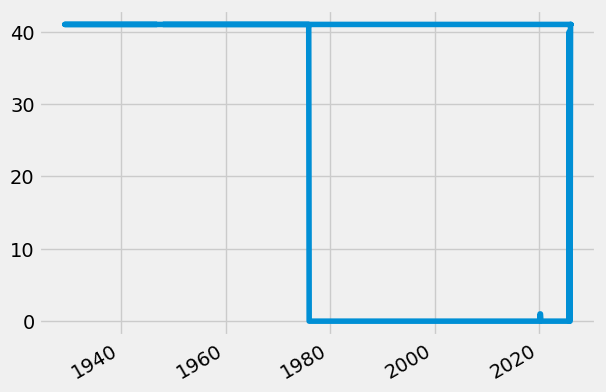

In [82]:
uemp_results.isna().sum(axis=1).plot()

In [83]:
uemp_states = uemp_results.copy()  #.drop('UNRATE', axis=1)
uemp_states = uemp_states.dropna()
id_to_state = unemp_df['title'].str.replace('Unemployment Rate in ','').to_dict()
uemp_states.columns = [id_to_state[c] for c in uemp_states.columns]

In [84]:
# Plot states unemployment rate
px.line(uemp_states)


### Pull April 2020 Unemployment Rate Per state
Could not get the "right" answer following the video.  Data set does not contain 2020-04-01 as an option.  used the check dates code to find this out.  

In [97]:
# Check dates around April 2020
april_2020 = uemp_states.loc['2020-04':'2020-04']
print("Available dates in April 2020:")
print(april_2020.index)

Available dates in April 2020:
DatetimeIndex([], dtype='datetime64[us]', freq=None)


In [98]:
# Check all 2020 dates
dates_2020 = uemp_states.loc['2020':'2020']
print("Available dates in 2020:")
print(dates_2020.index)

Available dates in 2020:
DatetimeIndex(['2020-01-01', '2020-02-01', '2020-05-01', '2020-06-01',
               '2020-07-01', '2020-08-01', '2020-09-01', '2020-10-01',
               '2020-11-01', '2020-12-01'],
              dtype='datetime64[us]', freq=None)


In [100]:
print(uemp_states.index.dtype)
print(uemp_states.index.min())
print(uemp_states.index.max())
print(uemp_states.index[:10])
print(uemp_states.index[-10:])



datetime64[us]
1976-01-01 00:00:00
2025-12-01 00:00:00
DatetimeIndex(['1976-01-01', '1976-02-01', '1976-03-01', '1976-04-01',
               '1976-05-01', '1976-06-01', '1976-07-01', '1976-08-01',
               '1976-09-01', '1976-10-01'],
              dtype='datetime64[us]', freq=None)
DatetimeIndex(['2025-02-01', '2025-03-01', '2025-04-01', '2025-05-01',
               '2025-06-01', '2025-07-01', '2025-08-01', '2025-09-01',
               '2025-11-01', '2025-12-01'],
              dtype='datetime64[us]', freq=None)


In [101]:
uemp_states.loc['2020-02-1':'2020-06-01']

,California,Texas,New York,Florida,Alabama,Illinois,Georgia,Michigan,Ohio,Mississippi,Pennsylvania,Louisiana,Massachusetts,Virginia,Minnesota,New Jersey,Kentucky,Missouri,North Carolina,Oregon,the District of Columbia,Wisconsin,Colorado,Nevada,Tennessee,Alaska,South Carolina,Maryland,Arizona,Puerto Rico,Washington,West Virginia,Iowa,Utah,Connecticut,Hawaii,New Mexico,Indiana,North Dakota,Arkansas,Oklahoma
2020-02-01,4.4,3.6,4.2,3.0,3.3,3.8,3.6,3.8,4.5,5.7,4.6,4.7,3.1,2.9,3.5,4.1,4.1,3.4,3.8,3.6,5.7,3.1,3.2,4.4,3.5,5.4,2.9,3.4,4.8,9.1,3.8,5.3,2.7,2.5,3.8,2.2,5.3,3.5,2.2,3.6,3.2
2020-05-01,15.8,11.7,16.7,14.1,10.4,14.7,9.8,19.3,12.8,11.2,12.9,12.3,14.3,10.0,11.1,15.4,12.8,9.6,11.6,11.8,8.8,10.5,11.7,24.7,12.1,11.7,9.3,8.8,11.2,8.9,13.6,12.5,8.5,7.7,11.9,20.7,9.3,12.5,7.3,8.9,9.8
2020-06-01,13.8,10.1,13.6,11.6,8.6,12.6,8.4,14.5,11.0,9.4,11.3,11.0,14.7,8.9,8.9,14.5,5.3,8.0,9.8,10.2,8.6,8.7,11.2,18.9,10.2,11.2,7.8,8.1,9.8,8.3,11.7,10.6,6.8,6.4,11.5,17.3,9.0,10.3,6.5,7.9,8.2


In [99]:
uemp_states.loc['2020-05-01'].sort_values(ascending=False)

Nevada                      24.7
Hawaii                      20.7
Michigan                    19.3
New York                    16.7
California                  15.8
New Jersey                  15.4
Illinois                    14.7
Massachusetts               14.3
Florida                     14.1
Washington                  13.6
Pennsylvania                12.9
Kentucky                    12.8
Ohio                        12.8
West Virginia               12.5
Indiana                     12.5
Louisiana                   12.3
Tennessee                   12.1
Connecticut                 11.9
Oregon                      11.8
Texas                       11.7
Colorado                    11.7
Alaska                      11.7
North Carolina              11.6
Arizona                     11.2
Mississippi                 11.2
Minnesota                   11.1
Wisconsin                   10.5
Alabama                     10.4
Virginia                    10.0
Georgia                      9.8
Oklahoma  

<Axes: title={'center': 'Unemployment Rate by State - May 2020'}>

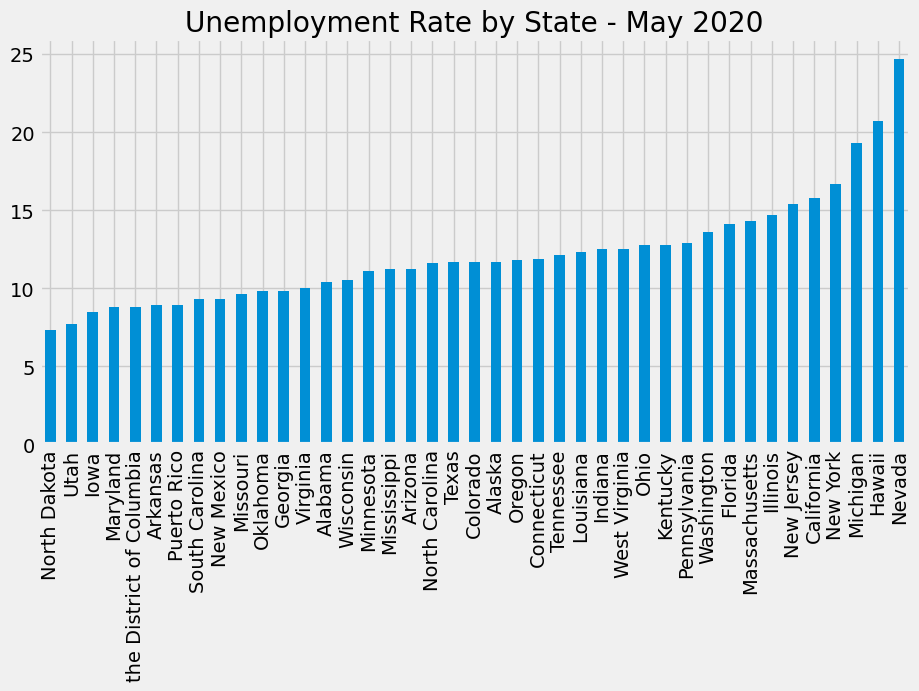

In [ ]:
uemp_states.loc['2020-05-01'].T \
    .sort_values() \
    .plot(kind='bar', figsize=(10,5),
          title='Unemployment Rate by State - May 2020')

### Pull Partcipation Rate